/var/folders/_7/r_r3pscs7s52j4fc3jqjmv3w0000gn/T/ipykernel_78259/4155929808.py:95: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


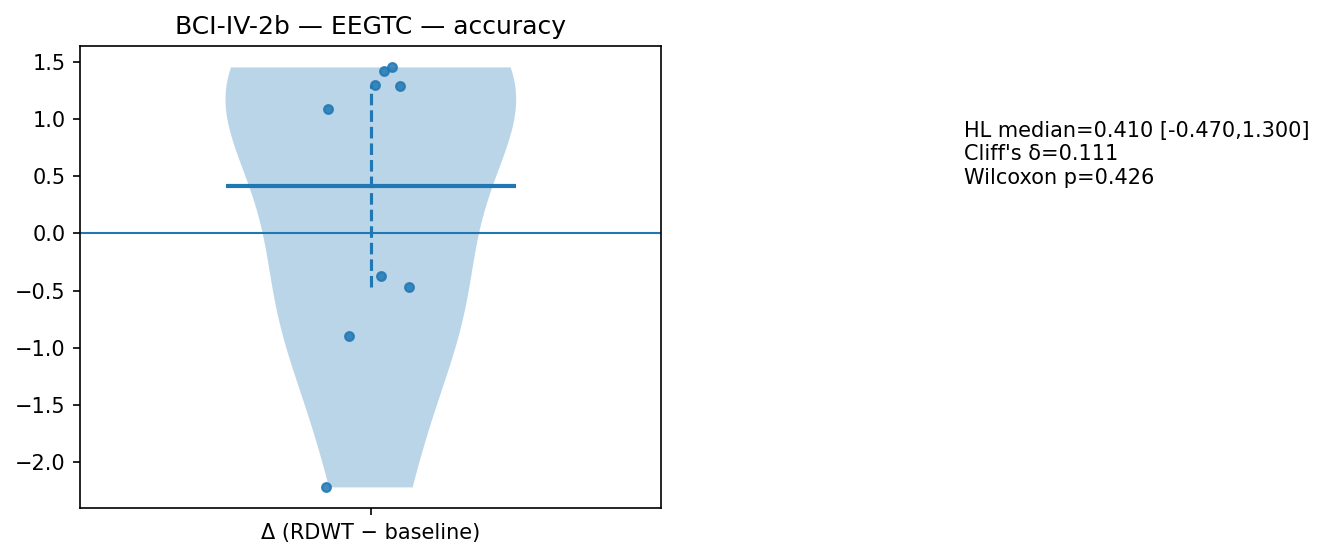

Saved: raincloud_delta_accuracy_EEGTC_BCI2b.png


/var/folders/_7/r_r3pscs7s52j4fc3jqjmv3w0000gn/T/ipykernel_78259/4155929808.py:95: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


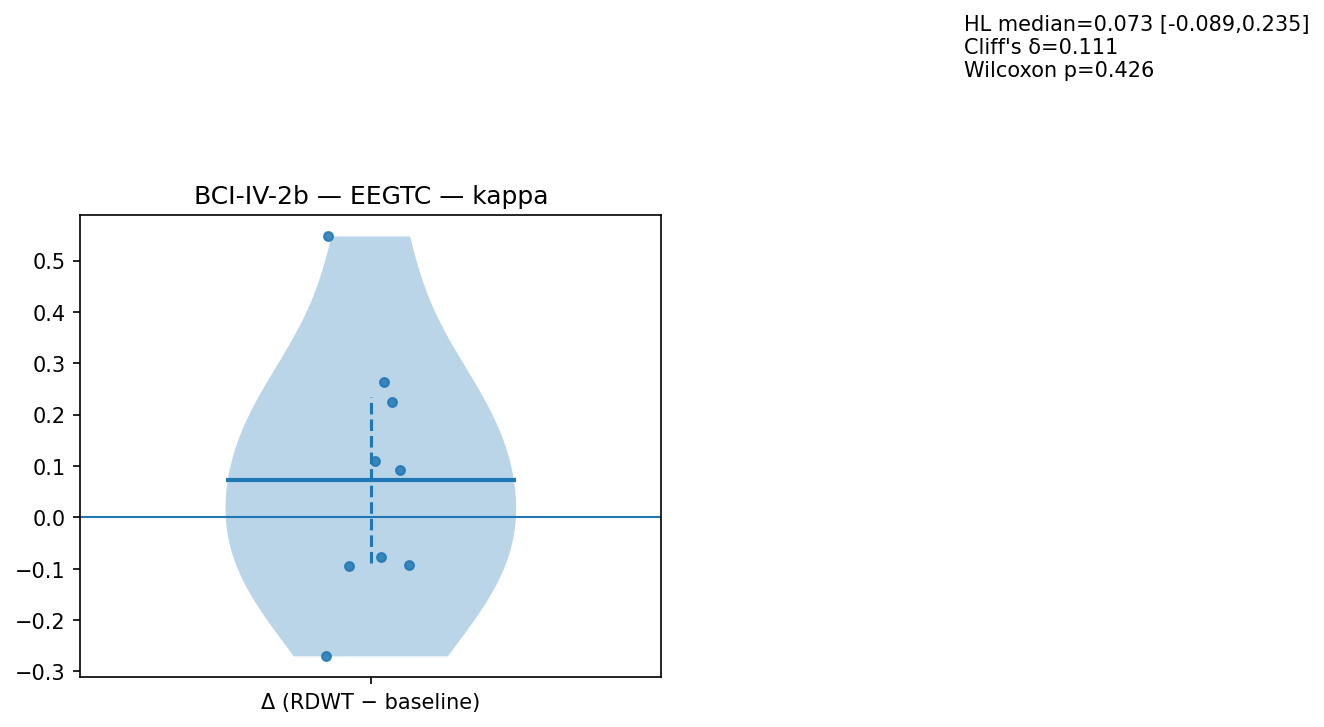

Saved: raincloud_delta_kappa_EEGTC_BCI2b.png


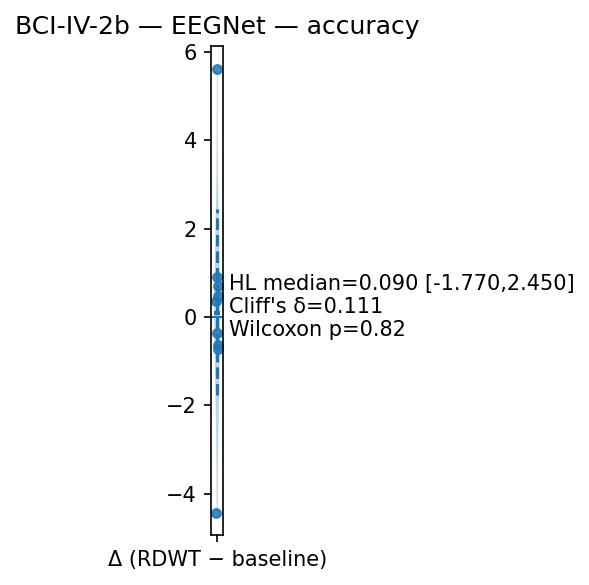

Saved: raincloud_delta_accuracy_EEGNet_BCI2b.png


/var/folders/_7/r_r3pscs7s52j4fc3jqjmv3w0000gn/T/ipykernel_78259/4155929808.py:95: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


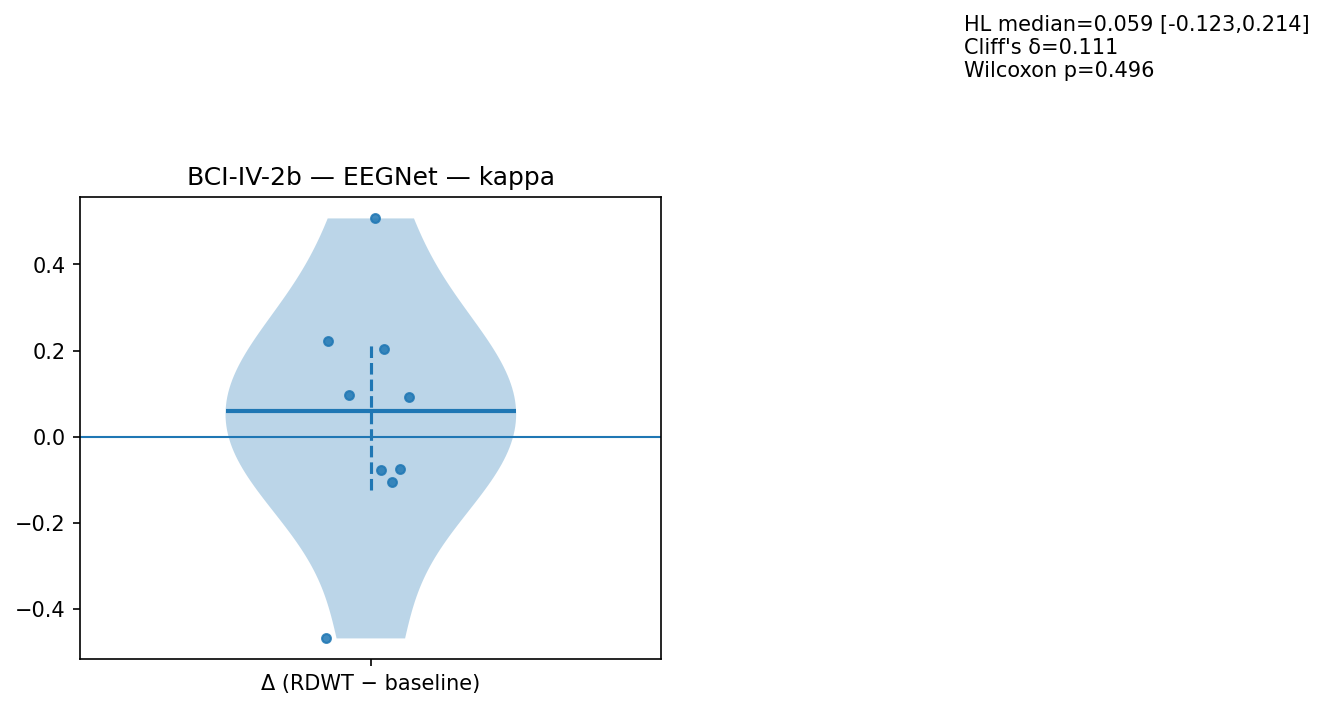

Saved: raincloud_delta_kappa_EEGNet_BCI2b.png


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:198: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


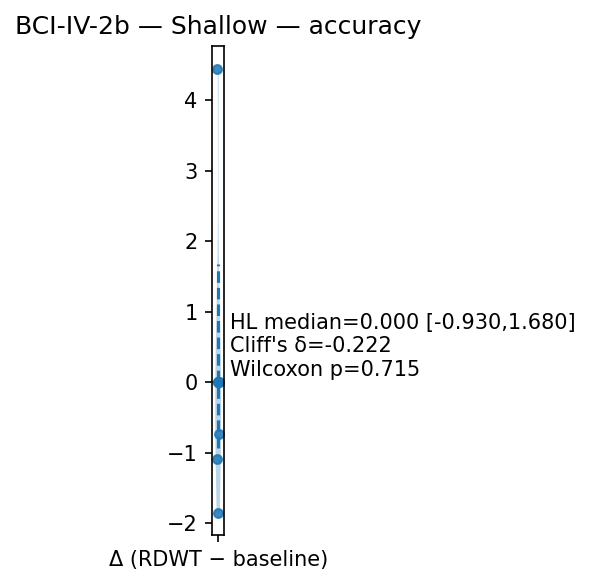

Saved: raincloud_delta_accuracy_Shallow_BCI2b.png


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:198: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
/var/folders/_7/r_r3pscs7s52j4fc3jqjmv3w0000gn/T/ipykernel_78259/4155929808.py:95: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


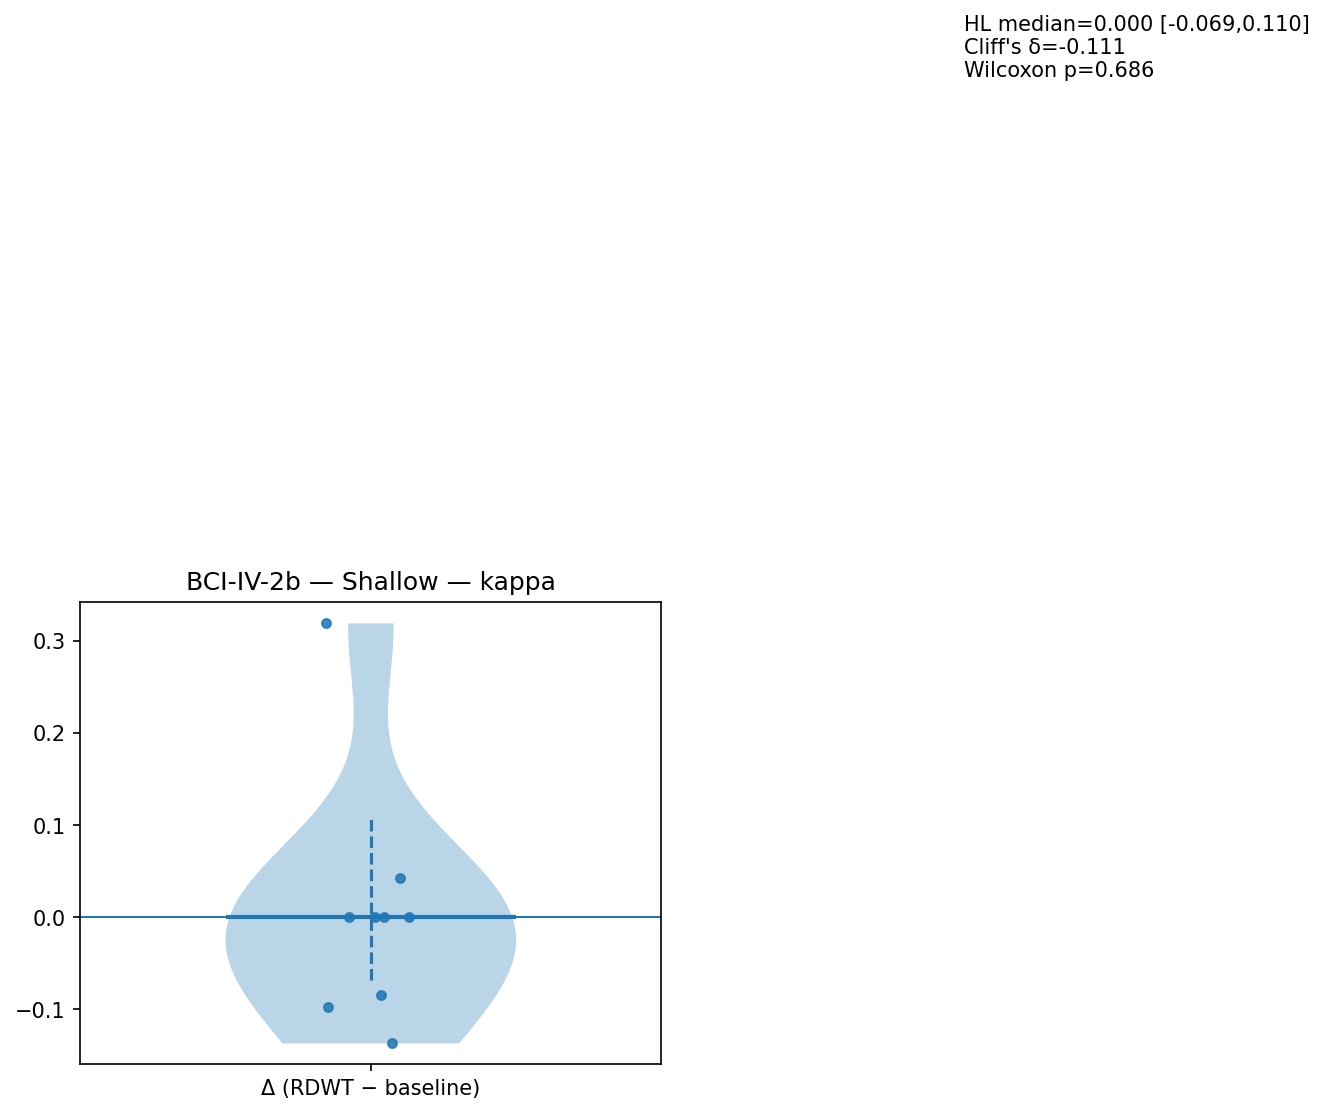

Saved: raincloud_delta_kappa_Shallow_BCI2b.png


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:198: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
/var/folders/_7/r_r3pscs7s52j4fc3jqjmv3w0000gn/T/ipykernel_78259/4155929808.py:95: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


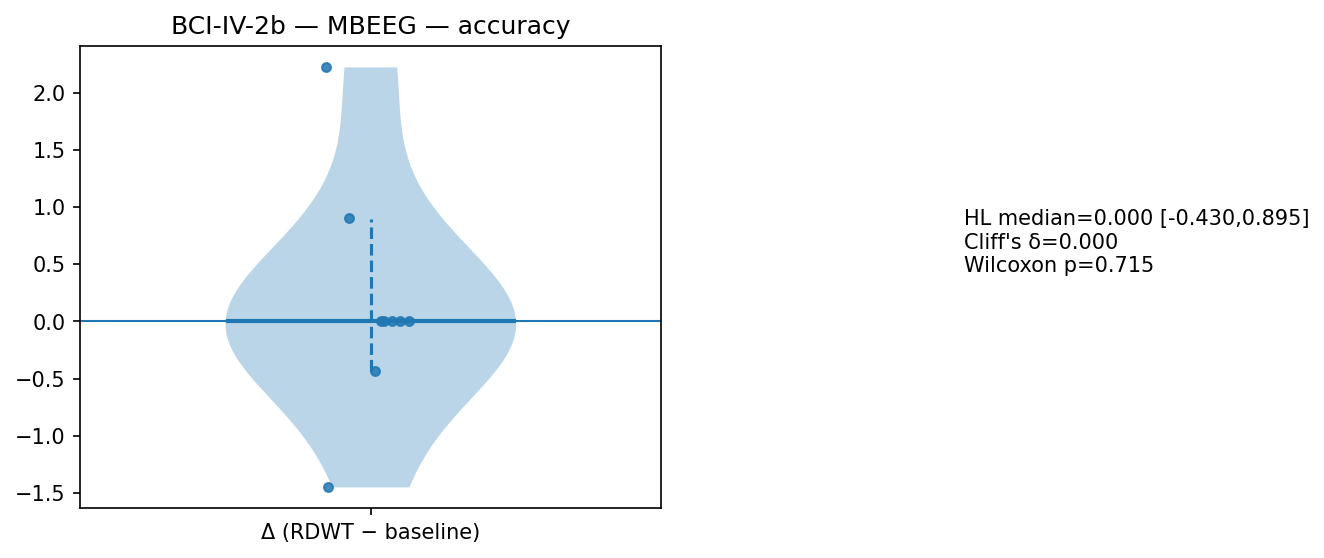

Saved: raincloud_delta_accuracy_MBEEG_BCI2b.png


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:198: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
/var/folders/_7/r_r3pscs7s52j4fc3jqjmv3w0000gn/T/ipykernel_78259/4155929808.py:95: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


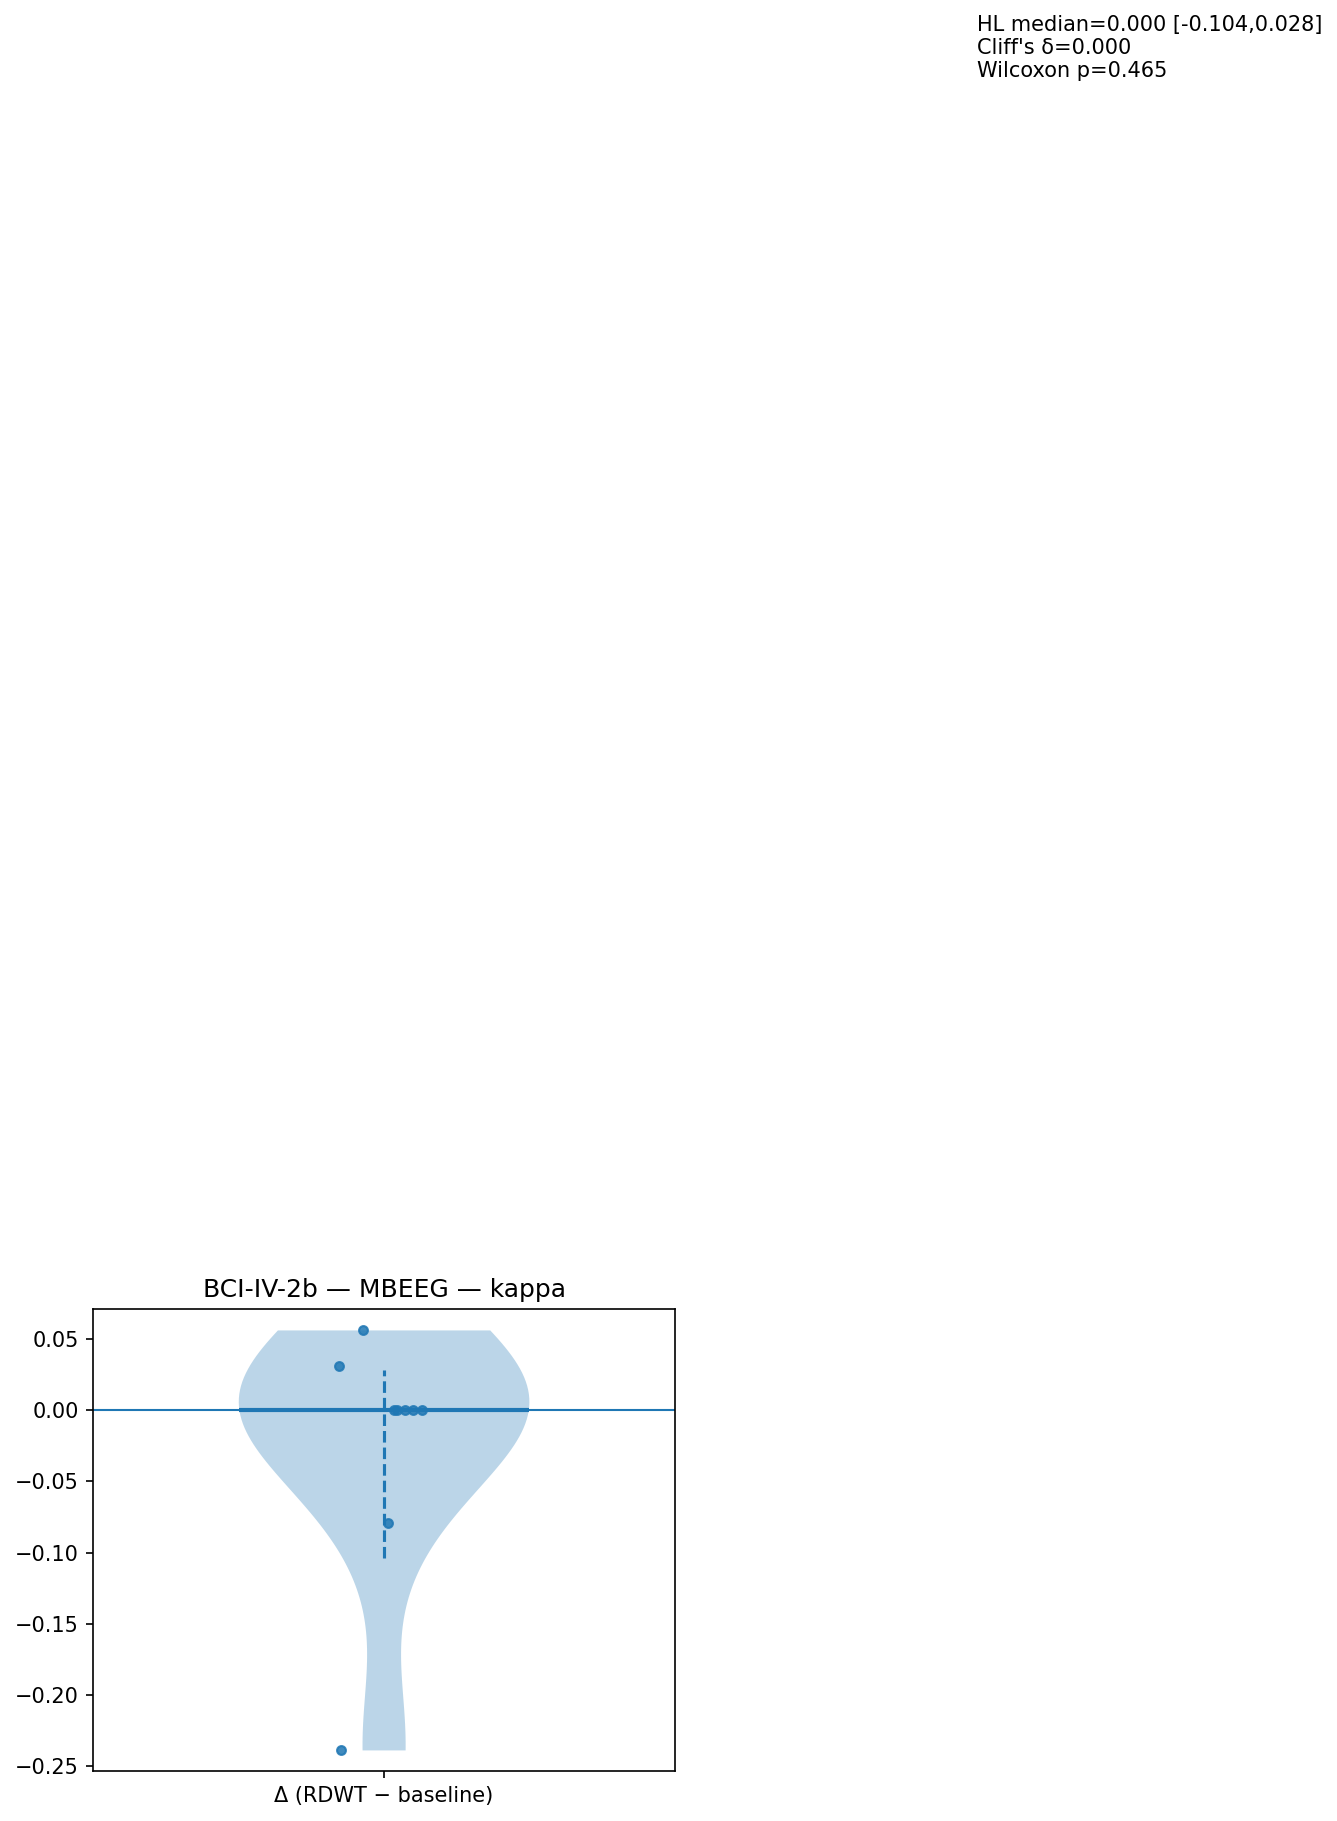

Saved: raincloud_delta_kappa_MBEEG_BCI2b.png


In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt

# (Opzionale) Wilcoxon; se manca scipy, il codice funziona lo stesso
try:
    from scipy.stats import wilcoxon
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False


def hodges_lehmann(x: np.ndarray) -> float:
    """Mediana di Hodges–Lehmann: mediana delle medie a coppie (x_i + x_j)/2."""
    x = np.asarray(x, dtype=float)
    m = (x[:, None] + x[None, :]) / 2.0
    return float(np.median(m))


def bootstrap_ci(x: np.ndarray, stat_fn, n_boot: int = 2000, alpha: float = 0.05, seed: int = 42):
    """IC bootstrap (percentile) per una statistica generica."""
    rng = np.random.default_rng(seed)
    n = len(x)
    boots = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        samp = x[rng.integers(0, n, n)]
        boots[b] = stat_fn(samp)
    lo = np.percentile(boots, 100 * (alpha / 2))
    hi = np.percentile(boots, 100 * (1 - alpha / 2))
    return float(lo), float(hi)


def cliffs_delta_against_zero(x: np.ndarray) -> float:
    """Cliff's δ contro zero: P(x>0) - P(x<0)."""
    x = np.asarray(x, dtype=float)
    gt = np.sum(x > 0)
    lt = np.sum(x < 0)
    n = len(x)
    return (gt - lt) / n if n > 0 else np.nan


def plot_raincloud_delta(baseline, rdwt, title="BCI-IV-2b — Model — metric", outfile="raincloud.png"):
    """
    Crea un grafico raincloud/violin per i delta per soggetto: (RDWT - baseline).
    - Nessun colore esplicito, solo matplotlib.
    - Un solo grafico per figura (no subplot).
    """
    baseline = np.asarray(baseline, dtype=float)
    rdwt = np.asarray(rdwt, dtype=float)
    if baseline.shape != rdwt.shape:
        raise ValueError("baseline e rdwt devono avere la stessa lunghezza (stessi soggetti).")

    deltas = rdwt - baseline

    fig, ax = plt.subplots(figsize=(5, 4), dpi=150)

    # Violin (nessun colore specificato)
    _ = ax.violinplot(deltas, showmeans=False, showextrema=False, showmedians=False)

    # Punti jitter (riproducibile)
    rng = np.random.default_rng(0)
    x0 = 1.0
    jitter = min(max(0.04 * (1 + 10 / len(deltas)), 0.02), 0.08)
    xs = x0 + rng.uniform(-jitter, jitter, size=len(deltas))
    ax.scatter(xs, deltas, s=18, alpha=0.85)

    # Mediana HL + IC 95% (bootstrap)
    hl = hodges_lehmann(deltas)
    lo, hi = bootstrap_ci(deltas, hodges_lehmann, n_boot=2000, alpha=0.05, seed=123)
    ax.hlines([hl], x0 - 0.25, x0 + 0.25, linestyles='solid', linewidth=2)
    ax.vlines([x0], lo, hi, linestyles='dashed', linewidth=1.5)

    # Linea di riferimento a zero
    ax.axhline(0.0, linewidth=1)

    # Assi e titolo
    ax.set_xlim(0.5, 1.5)
    ax.set_xticks([x0])
    ax.set_xticklabels(["Δ (RDWT − baseline)"])
    ax.set_title(title)

    # Statistiche a lato
    lines = [f"HL median={hl:.3f} [{lo:.3f},{hi:.3f}]",
             f"Cliff's δ={cliffs_delta_against_zero(deltas):.3f}"]
    if SCIPY_AVAILABLE:
        try:
            wstat, pval = wilcoxon(deltas, alternative='two-sided', zero_method="wilcox")
            lines.append(f"Wilcoxon p={pval:.3g}")
        except Exception:
            pass
    ax.text(1.52, 0.98, "\n".join(lines), transform=ax.get_yaxis_transform(), va='top')

    fig.tight_layout()
    fig.savefig(outfile)
    plt.show()
    plt.close(fig)
    print(f"Saved: {outfile}")


# =========================
# TUTTI I TUOI DATI (BCI-IV-2b)
# =========================
if __name__ == "__main__":
    # ---------- EEGTC ----------
    acc_none = [98.23, 99.10, 97.10, 84.44, 90.38, 100.00, 97.41, 98.19, 97.40]
    acc_rdwt = [99.65, 98.20, 98.19, 82.22, 91.67, 99.53, 97.04, 99.64, 98.70]
    plot_raincloud_delta(acc_none, acc_rdwt,
                         title="BCI-IV-2b — EEGTC — accuracy",
                         outfile="raincloud_delta_accuracy_EEGTC_BCI2b.png")

    k_none = [0.658, 0.918, -0.011, 0.502, 0.301, 1.000, 0.620, 0.697, 0.612]
    k_rdwt = [0.921, 0.824, 0.536, 0.231, 0.394, 0.907, 0.542, 0.921, 0.721]
    plot_raincloud_delta(k_none, k_rdwt,
                         title="BCI-IV-2b — EEGTC — kappa",
                         outfile="raincloud_delta_kappa_EEGTC_BCI2b.png")

    # ---------- EEGNet ----------
    acc_none = [98.58, 99.10, 98.19, 84.44, 92.95, 99.53, 97.41, 98.91, 93.51]
    acc_rdwt = [99.29, 100.00, 98.55, 80.00, 92.31, 100.00, 97.04, 98.19, 99.13]
    plot_raincloud_delta(acc_none, acc_rdwt,
                         title="BCI-IV-2b — EEGNet — accuracy",
                         outfile="raincloud_delta_accuracy_EEGNet_BCI2b.png")

    k_none = [0.593, 0.904, 0.436, 0.371, 0.446, 0.907, 0.620, 0.764, 0.322]
    k_rdwt = [0.797, 1.000, 0.659, -0.098, 0.370, 1.000, 0.542, 0.658, 0.829]
    plot_raincloud_delta(k_none, k_rdwt,
                         title="BCI-IV-2b — EEGNet — kappa",
                         outfile="raincloud_delta_kappa_EEGNet_BCI2b.png")

    # ---------- Shallow ----------
    acc_none = [99.65, 99.10, 97.83, 82.22, 91.67, 99.06, 95.19, 99.28, 98.70]
    acc_rdwt = [99.65, 99.10, 96.74, 86.67, 91.67, 99.06, 93.33, 98.55, 98.70]
    plot_raincloud_delta(acc_none, acc_rdwt,
                         title="BCI-IV-2b — Shallow — accuracy",
                         outfile="raincloud_delta_accuracy_Shallow_BCI2b.png")

    k_none = [0.907, 0.918, 0.389, 0.104, 0.394, 0.795, 0.462, 0.796, 0.794]
    k_rdwt = [0.907, 0.918, 0.291, 0.423, 0.437, 0.795, 0.378, 0.659, 0.794]
    plot_raincloud_delta(k_none, k_rdwt,
                         title="BCI-IV-2b — Shallow — kappa",
                         outfile="raincloud_delta_kappa_Shallow_BCI2b.png")

    # ---------- MBEEG ----------
    acc_none = [98.94, 98.20, 99.28, 82.22, 92.95, 100.00, 97.04, 98.91, 100.00]
    acc_rdwt = [98.94, 99.10, 97.83, 84.44, 92.95, 100.00, 97.04, 98.91, 99.57]
    plot_raincloud_delta(acc_none, acc_rdwt,
                         title="BCI-IV-2b — MBEEG — accuracy",
                         outfile="raincloud_delta_accuracy_MBEEG_BCI2b.png")

    k_none = [0.662, 0.848, 0.854, -0.071, 0.397, 1.000, 0.587, 0.764, 1.000]
    k_rdwt = [0.662, 0.904, 0.615, -0.040, 0.397, 1.000, 0.587, 0.764, 0.921]
    plot_raincloud_delta(k_none, k_rdwt,
                         title="BCI-IV-2b — MBEEG — kappa",
                         outfile="raincloud_delta_kappa_MBEEG_BCI2b.png")
